# Trabajo Práctico N°5 de TPS: Support Vector Machines (SVM)

En este trabajo práctico se estudia un problema de clasificación binaria aplicado al control de calidad industrial. A partir del dataset `ControlDeCalidad.txt`, se implementa desde cero el algoritmo SVM (Support Vector Machine), resolviendo su formulación dual mediante el solver `solve_qp`.

El objetivo principal es encontrar la frontera de decisión que maximiza el margen entre las dos clases.  
Además, se analiza cómo cambia dicha frontera al utilizar distintos kernels: lineal, polinómico y RBF, comparando su comportamiento y desempeño.

En primer lugar, se importan las librerías que se utilizarán a lo largo del mismo.

In [8]:
# Esta celda instala qpsolvers si hace falta
try:
    from qpsolvers import solve_qp
except ModuleNotFoundError:
    !pip install -q qpsolvers[clarabel]
    from qpsolvers import solve_qp

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qpsolvers import solve_qp

A continuación se carga el dataset de control de calidad. Cada fila representa un circuito integrado evaluado con dos pruebas diagnóstico, y la tercera columna indica si pasó la inspección (1) o no (-1).

In [10]:
try:
    data = np.loadtxt("ControlDeCalidad.txt")
except OSError:
    !curl -sL -o ControlDeCalidad.txt "https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/ControlDeCalidad.txt"
    data = np.loadtxt("ControlDeCalidad.txt")

X = data[:, :2]   # dos features de diagnóstico
y = data[:, 2]    # etiquetas originales: {0, 1}

# SVM necesita etiquetas en {-1, +1}
y = np.where(y == 0, -1, 1).astype(float)

# Verificación rápida
n, d = X.shape
clases, counts = np.unique(y, return_counts=True)
print(f"Muestras: {n} | Features: {d}")
print(f"Clases: {clases} | Distribución: {dict(zip(clases.astype(int), counts))}")


Muestras: 16 | Features: 2
Clases: [-1.  1.] | Distribución: {np.int64(-1): np.int64(8), np.int64(1): np.int64(8)}


## Exploración del dataset

Antes de arrancar con la implementación, se analiza la estructura del dataset para entender con qué se está trabajando.

In [11]:
# Tabla de datos
print(f"\n{'Muestra':>8}  {'Feature 1':>10}  {'Feature 2':>10}  {'Clase':>6}")
print(f"  {'-'*39}")
for i in range(n):
    clase_str = f"+{int(y[i])}" if y[i] > 0 else str(int(y[i]))
    print(f"  {i+1:>6}  {X[i,0]:>10.3f}  {X[i,1]:>10.3f}  {clase_str:>6}")

# Resumen del dataset
print(f"{'='*45}")
print(f"  RESUMEN DEL DATASET")
print(f"{'='*45}")
print(f"  Total de muestras : {n}")
print(f"  Features          : {d} (prueba diagnóstico 1 y 2)")
print(f"  Clases            : {clases.astype(int).tolist()}  (-1 = no aprueba, +1 = aprueba)")
print(f"  Muestras por clase: {dict(zip(clases.astype(int), counts))}")
print(f"  Rango feature 1   : [{X[:,0].min():.3f}, {X[:,0].max():.3f}]")
print(f"  Rango feature 2   : [{X[:,1].min():.3f}, {X[:,1].max():.3f}]")
print(f"{'='*45}")



 Muestra   Feature 1   Feature 2   Clase
  ---------------------------------------
       1       0.400      -0.700      -1
       2      -1.500      -1.000      -1
       3      -1.400      -0.900      -1
       4      -1.300      -1.200      -1
       5      -1.100      -0.200      -1
       6      -1.200      -0.400      -1
       7      -0.500       1.200      -1
       8      -1.500       2.100      -1
       9       1.000       1.000      +1
      10       1.300       0.800      +1
      11       1.200       0.500      +1
      12       0.200      -2.000      +1
      13       0.500      -2.400      +1
      14       0.200      -2.300      +1
      15       0.000      -2.700      +1
      16       1.300       2.100      +1
  RESUMEN DEL DATASET
  Total de muestras : 16
  Features          : 2 (prueba diagnóstico 1 y 2)
  Clases            : [-1, 1]  (-1 = no aprueba, +1 = aprueba)
  Muestras por clase: {np.int64(-1): np.int64(8), np.int64(1): np.int64(8)}
  Rango feature 1   : [

Del resumen y la tabla anteriores se pueden observar varias cosas relevantes:

- **Las features son mediciones normalizadas**: no representan magnitudes físicas directas sino resultados procesados de dos pruebas diagnóstico, ya centrados en cero. Esto es favorable para la SVM ya que evita que una feature domine a la otra al calcular distancias y productos internos.

- **Las etiquetas no vienen de una fórmula**: la clase de cada muestra proviene de una decisión del sistema de control de calidad (un criterio industrial o inspección). El objetivo no es reconstruir esa regla, sino aprender una frontera que separe las clases a partir de las mediciones.

- **Dataset pequeño y perfectamente balanceado**: 16 muestras con 8 por clase. El balance evita sesgos por desigualdad entre clases y hace que el margen que aprenda la SVM refleje genuinamente la geometría del problema.

- **Solo 2 features**: los datos pueden representarse en el plano $\mathbb{R}^2$, lo que va a permitir visualizar en detalle la frontera de decisión, los márgenes y los vectores soporte para cada kernel.

A continuación se grafica el scatter de los datos. Cada fila de la tabla se convierte en un punto en el plano: la Feature 1 va al eje $x$ y la Feature 2 al eje $y$. El color indica la clase.

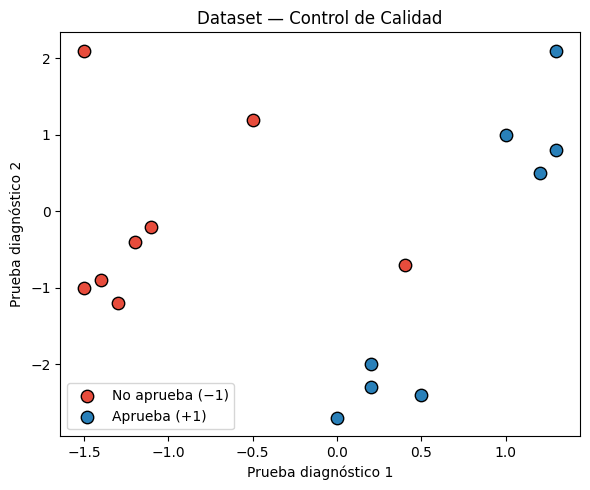

In [12]:
colores = {-1: "#e74c3c", 1: "#2980b9"}
etiquetas = {-1: "No aprueba (−1)", 1: "Aprueba (+1)"}

fig, ax = plt.subplots(figsize=(6, 5))
for clase in [-1, 1]:
    mask = y == clase
    ax.scatter(X[mask, 0], X[mask, 1],
               color=colores[clase], label=etiquetas[clase],
               edgecolors="k", s=80, zorder=3)

ax.set_xlabel("Prueba diagnóstico 1")
ax.set_ylabel("Prueba diagnóstico 2")
ax.set_title("Dataset — Control de Calidad")
ax.legend()
plt.tight_layout()
plt.show()

El scatter permite entender la geometría del problema antes de entrenar cualquier modelo. En este caso se observa que las dos clases están espacialmente separadas: las muestras que no aprueban (rojo) se concentran hacia la izquierda del plano, mientras que las que aprueban (azul) se ubican hacia la derecha y abajo. No hay mezcla caótica entre clases.

Esto anticipa que:
- El problema es linealmente separable (o casi), por lo que un kernel lineal debería funcionar bien.
- Los kernels no lineales (polinómico, RBF) encontrarán fronteras más curvas, lo cual puede ser innecesario, o incluso contraproducente, con tan pocas muestras.


## Ítem A: Formulación del Problema Dual

### La idea central: maximizar el margen

Dados dos conjuntos de puntos en el plano, hay infinitas rectas que los separan correctamente. La SVM elige una específica: la que deja la mayor distancia posible entre la recta y los puntos más cercanos de cada clase. Esa distancia se llama el margen, y la zona vacía que queda entre las dos clases funciona como una "calle". La SVM busca la calle más ancha posible.

¿Por qué interesa una calle ancha? Las mediciones del mundo real tienen ruido: si se mide el mismo circuito dos veces, no se obtiene exactamente el mismo valor. Si la frontera pasa cerca de un punto, cualquier pequeña variación puede cruzarla y generar una clasificación incorrecta. Una calle ancha actúa como zona de seguridad: el ruido tendría que ser muy grande para que un punto cruce al lado incorrecto. La analogía con los semiconductores es directa: cuanto mayor el gap de energía entre bandas, más energía térmica necesita un electrón para saltar. La SVM maximiza ese gap.

---

### Los vectores soporte

La idea es, por ejemplo, dos paredes paralelas que se quieren abrir lo máximo posible. Entre ellas hay columnas fijas (los datos de entrenamiento). Las paredes se abren hasta que alguna columna las detiene. Las columnas que quedan tocando las paredes son los vectores soporte: los puntos más cercanos a la frontera de cada clase. Todo lo demás está más adentro de su vereda; si esos puntos desaparecieran, la frontera no cambiaría. Solo moviendo un vector soporte se recalcula la calle entera.

La frontera tiene la forma $w^T x + b = 0$, donde $w$ es un vector perpendicular a la frontera y $b$ la desplaza. Los dos bordes del margen son $w^T x + b = +1$ y $w^T x + b = -1$, y la distancia entre ellos resulta $2/\|w\|$. Esto se debe a que, la distancia de un punto $x_0$ al hiperplano $w^T x = c$ es $|w^T x_0 - c| / \|w\|$. Tomando cualquier punto sobre el borde $+1$ (donde $w^T x_0 + b = 1$) y midiendo su distancia al borde $-1$:

$$\text{dist} = \frac{\bigl|(w^T x_0 + b) - (-1)\bigr|}{\|w\|} = \frac{|1 - (-1)|}{\|w\|} = \frac{2}{\|w\|}$$

El $b$ se cancela porque los planos son paralelos; el $2$ es simplemente $1-(-1)$, la diferencia entre los dos umbrales fijados por convención. Maximizar el margen equivale a minimizar $\|w\|$.

---

### El problema primal

$$\min_{w,\, b}\; \frac{1}{2}\|w\|^2 \qquad \text{sujeto a} \quad y_i\,(w^T x_i + b) \;\geq\; 1 \quad \forall\, i$$

La restricción cubre las dos clases a la vez gracias al factor $y_i \in \{-1, +1\}$: para clase $+1$ pide $w^T x_i + b \geq +1$; para clase $-1$, multiplicar por $-1$ da vuelta la desigualdad y pide $w^T x_i + b \leq -1$. Una sola expresión, dos condiciones; por eso las etiquetas son $\{-1, +1\}$ y no $\{0, 1\}$.

El objetivo de minimizar $\|w\|$ es análogo a regularización: se frena la magnitud de los pesos, pero no para evitar overfitting sino para maximizar la geometría del margen.

---

### El método Lagrange

Resolver el primal requiere manejar una restricción por cada punto. El método de Lagrange propone otra perspectiva: en lugar de imponer esas restricciones explícitamente, se asigna un "precio" $\alpha_i \geq 0$ a cada una y se incorpora al objetivo:

$$\mathcal{L}(w, b, \alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^n \alpha_i \bigl[\,y_i(w^T x_i + b) - 1\bigr]$$

En la solución óptima se debe cumplir para cada punto: $\alpha_i \cdot [y_i(w^T x_i + b) - 1] = 0$. Hay dos formas de que ese producto sea cero:
- **$\alpha_i = 0$**: el punto está lejos del borde, cumple la restricción con holgura → se ignora.
- **$y_i(w^T x_i + b) = 1$**: el punto está exactamente sobre el borde → $\alpha_i > 0$, es un vector soporte.

El solver no sabe de antemano quiénes son los soportes. Ajusta todos los $\alpha_i$ simultáneamente y la geometría sola determina cuáles terminan con $\alpha_i > 0$.

---

### El problema dual

Al derivar el Lagrangiano respecto a $w$ y $b$ e igualar a cero se obtiene que $w = \sum_i \alpha_i y_i x_i$ y $\sum_i \alpha_i y_i = 0$. Sustituyendo esto de vuelta, $w$ y $b$ desaparecen y el problema queda solo en función de los $\alpha_i$:

$$\max_{\alpha}\; \sum_{i=1}^n \alpha_i \;-\; \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i\,\alpha_j\,y_i\,y_j\,k(x_i,x_j) \qquad \text{s.a.} \quad \alpha_i \geq 0,\quad \sum_{i=1}^n \alpha_i\, y_i = 0$$

Donde $k(x_i, x_j)$ es el **kernel**, una función que mide cuán similares son dos puntos. En su versión más simple, el kernel lineal, es solo el producto punto $x_i^T x_j$ (qué tan "alineados" están dos vectores). Más adelante se usarán otros kernels (polinómico, RBF) que miden esa similitud de otras formas, lo que produce fronteras curvas. La ventaja del dual es que los datos solo aparecen dentro del kernel: cambiando esa función se cambia el tipo de frontera sin tocar nada más del algoritmo.

Leyendo el objetivo término a término: $\sum_i \alpha_i$ quiere crecer (ensanchar el margen); el doble sumatorio lo frena penalizando pares de puntos similares con la misma etiqueta. Si dos puntos de la misma clase son casi idénticos, uno es redundante y tener a los dos con $\alpha$ grande se penaliza. La restricción $\sum_i \alpha_i y_i = 0$ centra la frontera entre las dos clases.

---

### Traducción a `solve_qp`

`solve_qp` resuelve problemas de minimización cuadrática con restricciones lineales. El dual de SVM es exactamente eso. La función espera este formato:

$$\min_{\alpha} \; \frac{1}{2}\,\alpha^T P\,\alpha + q^T\alpha \qquad \text{s.a.} \quad G\alpha \leq h,\quad A\alpha = b$$

Como el dual maximiza, se niega el objetivo. Después se construye cada parámetro:

**`P`: la matriz de similitudes** ($n \times n$, nomenclatura estándar; el apunte la llama $Q$): cada entrada $P_{ij} = y_i\,y_j\,k(x_i,x_j)$ mide la similitud entre los puntos $i$ y $j$ ponderada por si tienen la misma etiqueta ($+1$) o distinta ($-1$). Es el doble sumatorio del dual, escrito en forma matricial.

**`q`: el término lineal** ($n \times 1$): es $q = -\mathbf{1}$, un vector de $-1$s. Viene de negar $\sum_i \alpha_i$.

**`G` y `h`: la restricción $\alpha_i \geq 0$**: `solve_qp` solo entiende desigualdades de la forma $G\alpha \leq h$. La restricción que se necesita es $\alpha_i \geq 0$, que es lo mismo que $-\alpha_i \leq 0$. Entonces $G = -I$ (identidad negada) y $h = \mathbf{0}$. Dos parámetros para escribir una sola restricción en el formato que impone la función.

**`A` y `b`: la restricción $\sum \alpha_i y_i = 0$**: `solve_qp` también entiende igualdades de la forma $A\alpha = b$. La restricción necesaria es $y^T \alpha = 0$, así que $A = y^T$ (el vector de etiquetas puesto en fila) y $b = 0$.


## Ítem B: Implementación de la Clase SVM

Se implementa la clase `SVM` con cuatro métodos. El flujo es el siguiente:

- **`__init__`**: recibe la función kernel y el hiperparámetro $\gamma$. Solo inicializa atributos, no hace cuentas.
- **`fit`**: construye las matrices del problema dual, llama a `solve_qp`, identifica los vectores soporte (los $\alpha_i > 0$) y calcula el bias $b$.
- **`predict_soft`**: devuelve la función de decisión $z(x) = \sum_i \alpha_i\, y_i\, k(x_i, x) + b$ para puntos nuevos. El valor de $z$ indica de qué lado de la frontera cae el punto y con qué margen.
- **`predict`**: aplica $\text{signo}(z(x))$ y devuelve la clase predicha: $-1$ o $+1$.

El bias se calcula como el promedio de $y_k - \sum_i \alpha_i y_i k(x_i, x_k)$ sobre todos los vectores soporte, para mayor robustez numérica.


In [13]:
import warnings

class SVM:
    def __init__(self, kernel, gamma=1.0, tol=1e-5):
        self.kernel = kernel
        self.gamma = gamma
        self.tol = tol

    def fit(self, X, y):
        n = len(y)

        # Matriz del kernel entre todos los pares de puntos de entrenamiento (n x n)
        K = self.kernel(X, X, self.gamma)

        # Construcción de las matrices para solve_qp
        P = (np.outer(y, y) * K).astype(float)  # P[i,j] = y_i * y_j * k(x_i, x_j)
        q = -np.ones(n)
        G = -np.eye(n)          # restricción alpha_i >= 0 → -alpha_i <= 0
        h = np.zeros(n)
        A = y.reshape(1, -1).astype(float)  # restricción sum(alpha_i * y_i) = 0
        b_eq = np.zeros(1)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            alphas = solve_qp(P, q, G, h, A, b_eq, solver="clarabel")

        # Vectores soporte: puntos con alpha_i significativamente mayor que cero
        sv_mask = alphas > self.tol
        self.sv_X = X[sv_mask]
        self.sv_y = y[sv_mask]
        self.sv_alpha = alphas[sv_mask]

        # Bias: para cada vector soporte, b_k = y_k - sum_i(alpha_i * y_i * k(x_i, x_k))
        # Se promedia sobre todos los vectores soporte para mayor estabilidad numérica
        K_sv = self.kernel(self.sv_X, X, self.gamma)   # n_sv x n
        decision_sv = K_sv @ (alphas * y)
        self.b = float(np.mean(self.sv_y - decision_sv))

    def predict_soft(self, X):
        # z(x) = sum_{sv} alpha_i * y_i * k(x_i, x) + b
        K = self.kernel(X, self.sv_X, self.gamma)      # m x n_sv
        return K @ (self.sv_alpha * self.sv_y) + self.b

    def predict(self, X):
        return np.sign(self.predict_soft(X))

El kernel aparece en tres momentos distintos dentro de la clase:

1. En `fit`, para calcular la similitud entre todos los pares de puntos de entrenamiento → $K \in \mathbb{R}^{n \times n}$
2. En `fit` al calcular el bias, para evaluar el kernel de los vectores soporte contra todos los de entrenamiento → $K \in \mathbb{R}^{n_{sv} \times n}$
3. En `predict_soft`, para evaluar el kernel de los puntos nuevos contra los vectores soporte → $K \in \mathbb{R}^{m \times n_{sv}}$

En los tres casos la función recibe dos matrices de puntos y devuelve una matriz de similitudes. Implementarla así evita hacer un doble for sobre los pares y aprovecha las operaciones matriciales de numpy.

Para el kernel lineal, la similitud entre dos puntos es simplemente el producto punto $k(x_i, x_j) = x_i^T x_j$. Extendido a dos conjuntos de puntos $X_1 \in \mathbb{R}^{n \times d}$ y $X_2 \in \mathbb{R}^{m \times d}$, la matriz de similitudes es $K = X_1 X_2^T \in \mathbb{R}^{n \times m}$, que es una sola multiplicación matricial.


## Ítem C: Kernel Lineal

El kernel lineal mide la similitud entre dos puntos como su producto punto:

$$k(x_i, x_j) = x_i^T x_j$$

Es el caso más simple (el producto punto): no transforma los datos a ningún espacio distinto, trabaja directamente en el espacio original. La frontera que produce es siempre una recta (en 2D), lo que tiene sentido para este dataset, ya que se observó que es linealmente separable.

A continuación se define el kernel, se entrena el modelo y se reporta el accuracy de entrenamiento y el margen unilateral. El margen unilateral es $1/\|w\|$, y $w$ puede recuperarse en el caso lineal como $w = \sum_i \alpha_i y_i x_i$ a partir de los vectores soporte.


In [14]:
def kernel_lineal(X1, X2, gamma=None):
    return X1 @ X2.T

# Entrenamiento
svm_lin = SVM(kernel=kernel_lineal)
svm_lin.fit(X, y)

# Accuracy de entrenamiento
y_pred = svm_lin.predict(X)
accuracy = np.mean(y_pred == y)

# Margen unilateral: 1/||w||
# En el caso lineal: w = sum_i alpha_i * y_i * x_i (solo sobre vectores soporte)
w = svm_lin.sv_alpha @ (svm_lin.sv_y[:, None] * svm_lin.sv_X)
margen = 1.0 / np.linalg.norm(w)

print(f"Accuracy de entrenamiento : {accuracy:.2%}")
print(f"Vectores soporte          : {len(svm_lin.sv_X)}")
print(f"Margen unilateral (1/||w||): {margen:.4f}")

Accuracy de entrenamiento : 100.00%
Vectores soporte          : 3
Margen unilateral (1/||w||): 0.0678


El 100% de accuracy sobre los datos de entrenamiento era esperable pero no trivial. La SVM de margen duro exige que todos los puntos queden del lado correcto del margen, si el dataset no fuera linealmente separable el solver directamente no encontraría solución. El hecho de que haya convergido y clasificado todo correctamente confirma que los datos son linealmente separables, consistente con lo que se anticipó en el scatter.

El margen unilateral (0.0678): refleja cuán ancha es la calle que la SVM logró abrir. Los kernels no lineales generarán fronteras curvas que podrían adaptarse mejor o peor a la geometría real de los datos.

## Ítem D: Visualización de la frontera de decisión

La función `predict_soft` devuelve $z(x) = \sum_i \alpha_i y_i k(x_i, x) + b$ para cualquier punto del plano. El valor de $z$ es la distancia con signo a la frontera, medida en unidades del margen: los vectores soporte tienen $z = \pm 1$ por construcción, la frontera está en $z = 0$, y cualquier punto bien clasificado tiene $|z| > 1$.

Para graficar esto, se evalúa $z$ en una grilla densa que cubre el plano. El resultado es un número por cada punto de la grilla, y las curvas de nivel unen los puntos donde ese número es el mismo, igual que las líneas de altitud en un mapa topográfico. Las tres que interesan son $z \in \{-1, 0, +1\}$: los dos bordes del margen y la frontera de decisión.

`contourf` colorea las regiones a cada lado de $z = 0$; `contour` traza las tres isolíneas. Para kernels no lineales las curvas dejarán de ser rectas, pero el código funciona igual.


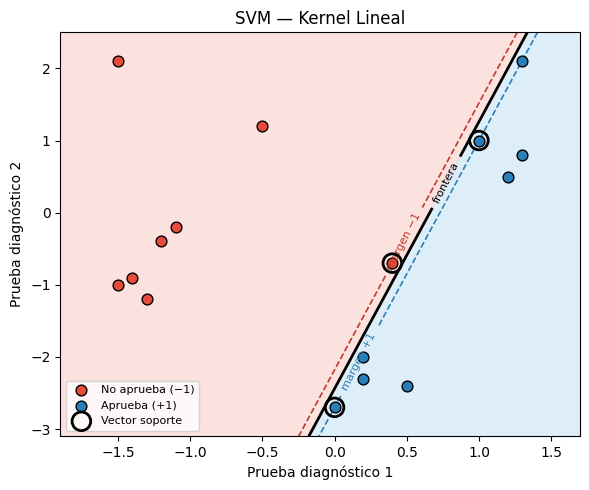

In [15]:
def plot_svm(svm, X, y, titulo="SVM"):
    margen_plot = 0.4
    x1_min, x1_max = X[:, 0].min() - margen_plot, X[:, 0].max() + margen_plot
    x2_min, x2_max = X[:, 1].min() - margen_plot, X[:, 1].max() + margen_plot

    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                           np.linspace(x2_min, x2_max, 300))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    Z = svm.predict_soft(grid).reshape(xx1.shape)

    fig, ax = plt.subplots(figsize=(6, 5))

    # Fondo coloreado por región de decisión
    ax.contourf(xx1, xx2, Z, levels=[-np.inf, 0, np.inf],
                colors=["#f5b7b1", "#aed6f1"], alpha=0.4)

    # Frontera (z=0) y márgenes (z=±1)
    cs = ax.contour(xx1, xx2, Z, levels=[-1, 0, 1],
                    colors=["#c0392b", "k", "#2980b9"],
                    linestyles=["--", "-", "--"], linewidths=[1.2, 2, 1.2])
    ax.clabel(cs, fmt={-1: "margen −1", 0: "frontera", 1: "margen +1"},
              fontsize=8)

    # Datos
    colores = {-1: "#e74c3c", 1: "#2980b9"}
    etiquetas = {-1: "No aprueba (−1)", 1: "Aprueba (+1)"}
    for clase in [-1, 1]:
        mask = y == clase
        ax.scatter(X[mask, 0], X[mask, 1],
                   color=colores[clase], label=etiquetas[clase],
                   edgecolors="k", s=60, zorder=3)

    # Vectores soporte resaltados
    ax.scatter(svm.sv_X[:, 0], svm.sv_X[:, 1],
               s=180, facecolors="none", edgecolors="k",
               linewidths=2, zorder=4, label="Vector soporte")

    ax.set_xlabel("Prueba diagnóstico 1")
    ax.set_ylabel("Prueba diagnóstico 2")
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    plt.tight_layout()
    plt.show()

plot_svm(svm_lin, X, y, titulo="SVM — Kernel Lineal")

Del gráfico se pueden observar los siguientes puntos:

- **Frontera recta**: el kernel lineal opera directamente en el espacio original sin ninguna transformación, por lo que la frontera es siempre una recta. En este caso separa las dos clases de forma limpia.
- **Margen angosto**: las líneas punteadas ($z = \pm 1$) están muy próximas a la frontera (margen unilateral = 0.0678), lo que indica que ambas nubes de puntos se acercan bastante entre sí en la dirección perpendicular a la frontera.
- **3 vectores soporte**: uno del lado negativo y dos del lado positivo. Son los únicos puntos que definen completamente la posición y orientación de la frontera; el resto del dataset es irrelevante para ella.
- **Separación perfecta**: ningún punto queda del lado incorrecto, lo cual confirma que el dataset es linealmente separable.


## Ítem E: Kernel Polinómico

El kernel polinómico de grado 3 tiene la forma:

$$k(x_i, x_j) = (\gamma \cdot x_i^T x_j)^3, \qquad \gamma = 0.3$$

Esta es la versión sin término independiente ($r = 0$). La forma más general es $(\gamma \cdot x_i^T x_j + r)^3$: con $r > 0$ también aparecerían términos de grado 1 y 2 en el espacio implícito, dando una frontera más flexible. Con $r = 0$ el espacio implícito contiene únicamente monomios de grado exactamente 3, que es la elección del enunciado.

---

### El espacio implícito: de $\mathbb{R}^2$ a $\mathbb{R}^4$

Elevar al cubo el producto punto equivale a operar en un espacio de mayor dimensión, sin calcularlo explícitamente. Con $x = (x_1, x_2)$, los monomios de grado 3 que se pueden formar son exactamente 4:

$$\phi(x) = \bigl(x_1^3,\; \sqrt{3}\,x_1^2 x_2,\; \sqrt{3}\,x_1 x_2^2,\; x_2^3\bigr) \in \mathbb{R}^4$$

El número de dimensiones del espacio implícito siempre sigue la fórmula $\binom{p + d - 1}{d}$, donde $p$ es la cantidad de features originales y $d$ el grado. Acá: $\binom{2 + 3 - 1}{3} = \binom{4}{3} = 4$.

En ese espacio de 4 dimensiones, la SVM hace exactamente lo mismo que con el kernel lineal: busca el hiperplano con el margen más ancho. Ese hiperplano es $w^T \phi(x) + b = 0$, que es lineal en $\mathbb{R}^4$. Pero al sustituir $\phi(x)$ y proyectar de vuelta al plano original, la ecuación se convierte en un polinomio cúbico en $x_1$ y $x_2$: la curva de nivel cero de ese polinomio es lo que se ve como "frontera curva" en la visualización.

El Teorema de la Función Implícita (TFI) justifica que ese conjunto de nivel sea una curva suave: garantiza que en los puntos donde $\nabla F \neq 0$ (con $F(x_1, x_2) = w^T\phi(x) + b$), la ecuación $F = 0$ define localmente a $x_2$ como función diferenciable de $x_1$. En otras palabras, la frontera no puede tener "saltos" ni comportamientos patológicos; es una curva bien definida. El TFI no se usa para construir la frontera, sino para garantizar que existe y es suave.

---

### El rol de $\gamma$

$\gamma$ escala el producto punto antes de elevarlo al cubo. Actúa como una normalización implícita: evita que valores grandes de $x_i^T x_j$ se disparen al cubicarlos, lo que desestabilizaría el solver. Si los datos ya estuvieran normalizados, $\gamma = 1$ funcionaría bien; con datos de mayor varianza, $\gamma$ chico comprime los valores antes de la potencia. También controla la curvatura de la frontera: $\gamma$ mayor amplifica las diferencias entre similitudes, produciendo curvas más pronunciadas.

---

### El precio del truco del kernel: $w$ inaccesible

Todo el algoritmo SVM (construir la matriz $P$, calcular el bias y predecir) usa únicamente productos internos entre pares de puntos. Nunca necesita los vectores $\phi(x)$ en sí. Eso es precisamente el truco del kernel: se aprovecha el producto interno de un espacio al que nunca se calcularon los vectores generadores.

El precio de ese ahorro es que $w = \sum_i \alpha_i y_i \phi(x_i)$ vive en $\mathbb{R}^4$ y, como nunca se materializó $\phi(x)$, tampoco se puede materializar $w$. Sin $w$ explícito no hay $\|w\|$, y sin $\|w\|$ no hay margen unilateral interpretable. Por eso no se reporta ese valor para este kernel ni para el RBF. No es una limitación del dataset, sino una consecuencia directa de cómo funciona el truco.


In [16]:
def kernel_poly(X1, X2, gamma=0.3):
    return (gamma * X1 @ X2.T) ** 3

# Entrenamiento
svm_poly = SVM(kernel=kernel_poly, gamma=0.3)
svm_poly.fit(X, y)

# Accuracy de entrenamiento
y_pred = svm_poly.predict(X)
accuracy = np.mean(y_pred == y)

print(f"Accuracy de entrenamiento : {accuracy:.2%}")
print(f"Vectores soporte          : {len(svm_poly.sv_X)}")

Accuracy de entrenamiento : 100.00%
Vectores soporte          : 4


El 100% de accuracy es esperable y no sorprende: con margen duro, un kernel más expresivo nunca puede ser peor que el lineal. Si el dataset es linealmente separable, el espacio implícito de grado 3 siempre contiene al espacio original como caso particular, así que el solver siempre puede encontrar al menos esa frontera.

Lo que sí cambia es que ahora hay 4 vectores soporte en lugar de 3. Eso refleja que la frontera curva se apoya en una geometría distinta: al doblarse para seguir el contorno de los datos, necesita más puntos que la sostengan.

Hay dos cosas que este 100% no garantiza. Primero, no dice nada sobre generalización: con 16 muestras y una frontera cúbica, el modelo tiene margen para memorizar. Si hubiera un conjunto de test, probablemente el lineal generalizaría mejor, ya que la curvatura extra no está justificada por los datos. Segundo, el 100% en entrenamiento con margen duro es casi siempre el resultado cuando el dataset es separable: con grado par y $r=0$ podría haber problemas de convergencia (la matriz del kernel puede dejar de ser semidefinida positiva), pero con grado impar esto no ocurre.

A continuación se visualiza la frontera para analizar la forma de la curva.


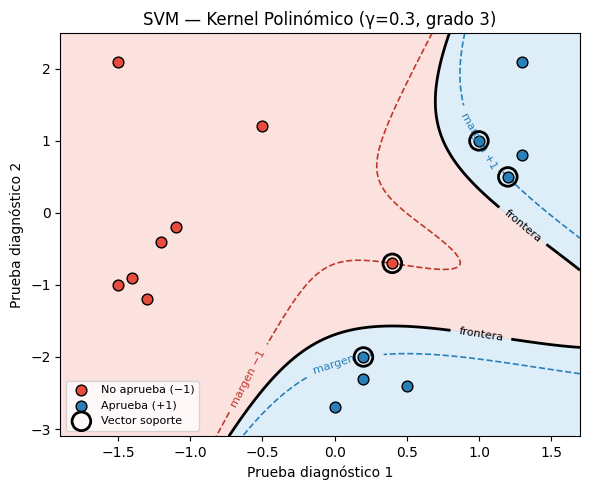

In [17]:
plot_svm(svm_poly, X, y, titulo="SVM — Kernel Polinómico (γ=0.3, grado 3)")

Del gráfico se pueden observar los siguientes puntos:

- **Frontera en dos ramas**: a diferencia del kernel lineal, la frontera ya no es una única recta sino una curva cúbica que aparece dividida en dos tramos. Esto es matemáticamente válido: el conjunto de nivel cero de un polinomio cúbico puede tener múltiples componentes conexas. Las dos regiones azules, una arriba a la derecha y otra abajo, podrían estar conectadas fuera del rango visible del plot, pero eso no cambia el análisis dentro de la zona de los datos.

- **Zonas de decisión cuestionables**: la región roja que queda entre las dos islas azules implica que un nuevo punto azul que cayera en esa franja sería clasificado incorrectamente como $-1$. No es un error sobre los datos de entrenamiento, todos están bien clasificados, sino una señal de que la frontera aprendió una forma más compleja de lo que los datos justifican.

- **4 vectores soporte**: uno más que el kernel lineal. La frontera más compleja necesita más puntos de apoyo para definir su forma.

- **Conclusión**: el kernel polinómico de grado 3 separa correctamente el dataset de entrenamiento, pero genera una topología de decisión más arriesgada que el lineal. Para datos nuevos en zonas intermedias del plano, el lineal probablemente generalizaría mejor, es más simple y suficiente para este problema.

## Ítem F: Kernel RBF

El kernel RBF (*Radial Basis Function*) tiene la forma:

$$k(x_i, x_j) = e^{-\gamma \|x_i - x_j\|^2}, \qquad \gamma = 1.0$$

### La idea intuitiva: señales que se difuminan

A diferencia del kernel lineal y el polinómico, que miden similitud por producto punto (qué tan alineados están dos vectores), el RBF mide similitud por distancia: dos puntos son similares si están cerca en el espacio, sin importar en qué dirección.

La analogía es directa con las antenas de telefonía móvil: cada torre emite una señal que se va difuminando con la distancia. El teléfono sabe a qué celda pertenece según qué torres lo "sienten" cerca. En el RBF pasa lo mismo: cada punto de entrenamiento emite una "señal" gaussiana centrada en él, y la frontera de decisión emerge de la superposición de todas esas señales. El límite queda donde los votos de clase $+1$ y los de clase $-1$ se equilibran.

Cuando $\|x_i - x_j\|^2 = 0$ (mismo punto), $k = 1$ (máxima similitud). A medida que se alejan, la exponencial cae hacia cero.

---

### El rol de $\gamma$ y su elección

$\gamma$ controla qué tan rápido se difumina esa señal con la distancia:

- **$\gamma$ grande**: la campana muere rápido, cada punto influye solo a sus vecinos inmediatos, la frontera queda muy retorcida y adaptada punto a punto, con riesgo de overfitting.
- **$\gamma$ chico**: la campana se difumina despacio, cada punto "siente" a vecinos lejanos, la frontera queda suave. En el límite $\gamma \to 0$, todas las campanas se aplanan tanto que cada punto "ve" a todos los demás por igual: la frontera degenera en una recta, comportándose como el kernel lineal.

La elección de $\gamma$ es crítica: un valor malo puede arruinar el modelo en cualquiera de los dos extremos. En la práctica se elige mediante cross-validation: se evalúa una grilla de valores de $\gamma$ (típicamente en escala logarítmica, $10^{-3}, 10^{-2}, \ldots, 10^{2}$) y se selecciona el que minimiza el error de validación. Este proceso suele combinarse con la búsqueda del hiperparámetro $C$ del margen blando, haciendo una búsqueda en grilla 2D.

Con $\gamma = 1.0$ en este dataset se tiene una influencia moderada, pero sin un conjunto de validación no se puede afirmar que sea el valor óptimo.

---

### El espacio implícito: dimensión infinita

Al igual que con el kernel polinómico, el RBF corresponde a un mapeo implícito $\phi(x)$ tal que $k(x_i, x_j) = \phi(x_i)^T \phi(x_j)$. La diferencia es que ese espacio es de dimensión infinita; no existe un $\phi(x)$ finito que lo represente explícitamente.

Sin embargo, el algoritmo SVM nunca necesita materializar $\phi(x)$: solo usa productos internos entre pares de puntos, que son exactamente lo que devuelve $k$. Por eso se puede aprovechar un espacio infinito-dimensional sin pagar el costo computacional de operar en él.

El precio de ese truco es que $w = \sum_i \alpha_i y_i \phi(x_i)$ vive en ese espacio infinito y nunca se puede recuperar. Sin $w$ no hay $\|w\|$, y sin $\|w\|$ no hay margen unilateral calculable; por eso no se reporta ese valor para este kernel.

---

### ¿Por qué es el kernel más usado en la práctica?

El RBF es el kernel por defecto en la mayoría de las implementaciones de SVM (incluyendo `sklearn`). Es más flexible que el polinómico sin necesidad de elegir un grado, y más versátil que el lineal cuando la frontera real no es una recta. Con $\gamma$ bien elegido mediante cross-validation, generaliza muy bien.

El riesgo de overfitting es real, pero es exactamente el mismo riesgo que con cualquier modelo flexible: se controla con validación, no descartando el modelo.


In [18]:
def kernel_rbf(X1, X2, gamma=1.0):
    # ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 * x_i^T x_j
    # Forma vectorizada: evita doble for sobre los pares
    sq1 = np.sum(X1 ** 2, axis=1, keepdims=True)   # (n, 1)
    sq2 = np.sum(X2 ** 2, axis=1, keepdims=True)   # (m, 1)
    dists_sq = sq1 + sq2.T - 2 * X1 @ X2.T         # (n, m)
    return np.exp(-gamma * dists_sq)

# Entrenamiento
svm_rbf = SVM(kernel=kernel_rbf, gamma=1.0)
svm_rbf.fit(X, y)

# Accuracy de entrenamiento
y_pred = svm_rbf.predict(X)
accuracy = np.mean(y_pred == y)

print(f"Accuracy de entrenamiento : {accuracy:.2%}")
print(f"Vectores soporte          : {len(svm_rbf.sv_X)}")
print(f"Margen unilateral         : no calculable (w vive en dimensión infinita)")

Accuracy de entrenamiento : 100.00%
Vectores soporte          : 10
Margen unilateral         : no calculable (w vive en dimensión infinita)


A continuación se visualiza la frontera para observar la curvatura producida por el kernel RBF.


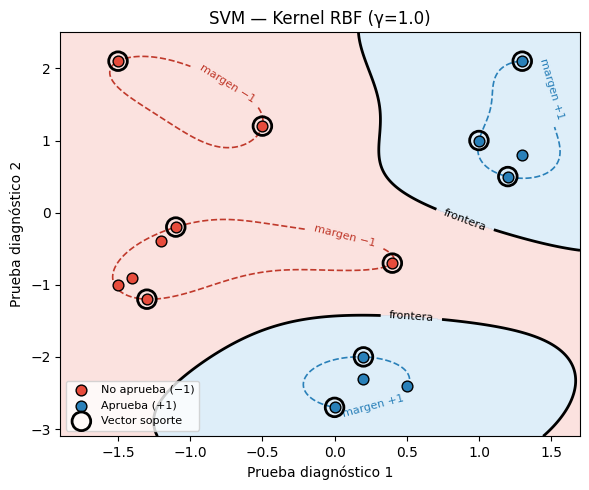

In [19]:
plot_svm(svm_rbf, X, y, titulo="SVM — Kernel RBF (γ=1.0)")

## Ítem G: Comparación y Conclusiones

### Tabla comparativa

| Kernel | Vectores soporte | % del dataset | Margen unilateral | Frontera |
|---|---|---|---|---|
| Lineal | 3 | 19% | 0.0678 | Recta |
| Polinómico (grado 3) | 4 | 25% | — | Curva cúbica |
| RBF ($\gamma=1.0$) | 10 | 62% | — | Curva libre |

---

### La paradoja del 100%

Los tres modelos alcanzan 100% de accuracy sobre los datos de entrenamiento. A primera vista parecen equivalentes. Pero son radicalmente distintos en complejidad: el lineal usa 3 puntos para definir su frontera, el RBF usa 10 de 16.

Esto demuestra que el accuracy de entrenamiento solo no dice nada sobre la calidad del modelo. Para evaluar realmente un clasificador se necesitan datos de test que el modelo nunca vio. Con solo 16 muestras y sin conjunto de validación, los tres modelos son indistinguibles por accuracy, pero son muy distintos en lo que harían con datos nuevos.

---

### Los vectores soporte como proxy de complejidad

Cuantos más vectores soporte tiene un modelo, más depende de los datos de entrenamiento para definir su frontera. Un modelo con pocos vectores soporte aprendió una regla general; uno con muchos aprendió a describir los datos que ya vio.

- **3 vectores soporte (lineal)**: la frontera existe independientemente del 81% restante del dataset. Si se removieran 13 puntos al azar, la frontera probablemente no cambiaría.
- **10 vectores soporte (RBF)**: el modelo depende del 62% de los datos. Es una señal clara de que la frontera está sobreajustada a la geometría particular de estas 16 muestras.

---

### El kernel adecuado para este problema

Para este dataset el kernel lineal es el más adecuado: el problema es linealmente separable (observado desde el scatter inicial), las clases están claramente separadas en el espacio original, y una frontera simple con 3 vectores soporte captura esa estructura sin agregar complejidad innecesaria.

El kernel polinómico y el RBF agregan capacidad expresiva que este dataset no justifica. Con tan pocas muestras, esa capacidad extra no se traduce en un mejor modelo, sino en una frontera más retorcida que probablemente generalizaría peor.

---

### Cuándo cambiaría la conclusión

El cuadro sería distinto si:

- **Los datos no fueran linealmente separables**: el lineal fallaría y el RBF con $\gamma$ bien elegido mediante cross-validation lo superaría.
- **Hubiera muchas más muestras**: con datos suficientes para hacer validación, el RBF puede encontrar estructuras no lineales genuinas sin memorizar ruido.
- **Hubiera mezcla entre clases**: el margen duro dejaría de tener solución y sería necesario pasar a soft margin, introduciendo el hiperparámetro $C$ que controla cuántas violaciones del margen se toleran.

---

### Limitación del margen duro

La implementación de este TP asume que los datos son perfectamente separables. En un problema real donde las clases se superponen, el solver no encontraría solución. La extensión natural es el soft margin, que introduce una variable de holgura $\xi_i \geq 0$ por cada punto:

$$\min_{w,b,\xi} \; \frac{1}{2}\|w\|^2 + C \sum_i \xi_i \qquad \text{s.a.} \quad y_i(w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

Donde $C$ controla el trade-off entre maximizar el margen y tolerar errores de clasificación. Con $C$ grande se penalizan mucho los errores (comportamiento similar al margen duro); con $C$ chico se acepta más ruido a cambio de un margen más ancho.
